In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torch.autograd import Variable
from torch.utils.data import TensorDataset # 텐서데이터셋
from torch.utils.data import DataLoader # 데이터로더
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import Dataset

from tqdm import tqdm

import sys
from pathlib import Path

project_root = Path.cwd().parent.parent
sys.path.append(str(project_root))

from src.config.settings import COMPRESSED_DATA_DIR, RESULT_PREDICTION_DIR

In [2]:
# GPU 설정
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(torch.cuda.get_device_name(0))

NVIDIA GeForce RTX 4080 SUPER


In [3]:
df = pd.DataFrame()
result = []

for file_path in tqdm(COMPRESSED_DATA_DIR.glob("*.csv"), desc="Loading CSV files"):
    df = pd.read_csv(file_path)
    result.append(df)
    
df = pd.concat(result, ignore_index=True)

Loading CSV files: 11it [00:15,  1.42s/it]


In [4]:
df['DPR_MT1_UNIT_TM'] = pd.to_datetime(df['DPR_MT1_UNIT_TM'])
df['ARV_MT1_UNIT_TM'] = pd.to_datetime(df['ARV_MT1_UNIT_TM'])

In [5]:
grouped = df.groupby('TRIP_NO')

In [6]:
summary = grouped.apply(lambda group: {
    "start_time": group['DPR_MT1_UNIT_TM'].min(),
    "end_time": group['ARV_MT1_UNIT_TM'].max(),
    "start_coords_x" : group.loc[group["DPR_MT1_UNIT_TM"].idxmin(), 'DPR_CELL_XCRD'],
    "start_coords_y" : group.loc[group["DPR_MT1_UNIT_TM"].idxmin(), 'DPR_CELL_YCRD'],
    "avg_speed": group['DYNA_MVMT_SPED'].mean(),
    "avg_movement": group['DYNA_DYN_KD_CD'].mean()
}).reset_index(name="summary")

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_79364\2699000528.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summary = grouped.apply(lambda group: {


In [7]:
summary_df = summary["summary"].apply(pd.Series)
summary_df["end_time_floor"] = summary_df["end_time"].dt.floor("h")

In [8]:
time_grouped = summary_df.groupby("end_time_floor").apply(
    lambda group: [
        len(group),
        group["start_coords_x"].mean(),
        group["start_coords_y"].mean(),
        group["avg_speed"].mean(),
        group["avg_movement"].mean()
    ]
).sort_index()

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_79364\2956515124.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  time_grouped = summary_df.groupby("end_time_floor").apply(


In [9]:
# 데이터프레임으로 변환
time_grouped_df = pd.DataFrame(
    time_grouped.tolist(),  # 리스트를 행으로 변환
    index=time_grouped.index,  # 인덱스를 기존 그룹화 인덱스에서 유지
    columns=["count", "x", "y", "speed", "movement"]  # 열 이름 지정
)

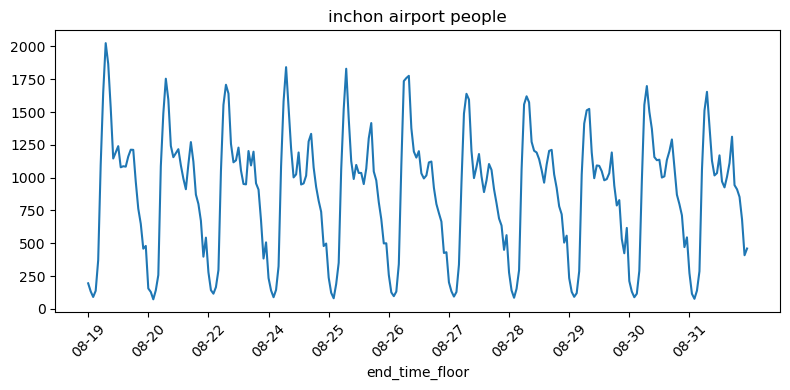

In [36]:
plot_df = time_grouped_df.copy()

plot_df["end_time_floor"] = time_grouped_df.index
plot_df.index = range(len(plot_df))

ax = plot_df["count"].plot(kind="line", figsize=(8,4), title="inchon airport people")

day_starts = plot_df.groupby(plot_df["end_time_floor"].dt.normalize()).head(1)
ax.set_xticks(day_starts.index)
ax.set_xticklabels(day_starts["end_time_floor"].dt.strftime("%m-%d"), rotation=45)

ax.set_xlabel("end_time_floor")
plt.tight_layout()
plt.show()
plt.close()

In [11]:
scaler = MinMaxScaler(feature_range=(0,1))
scaled = scaler.fit_transform(time_grouped_df)

In [12]:
# 테스트 데이터 설정
TEST_SIZE = int(len(scaled)*0.3)
train_data = scaled[:-TEST_SIZE]
test_data = scaled[-TEST_SIZE:]

In [13]:
# 데이터셋 생성 함수
def make_sample(data, i_window, o_window):  # window 단위로 데이터 분석 후 결과값 도출
    train = []
    target = []
    for i in range(len(data) - i_window - o_window + 1):
        train.append(data[i : i + i_window])
        target.append(data[i + i_window : i + i_window + o_window])
    return np.array(train), np.array(target)

X_train, y_train = make_sample(train_data, 24, 6)
X_test, y_test = make_sample(test_data, 24, 6)

In [14]:
# 텐서 변환
X_train_tensor = Variable(torch.Tensor(X_train)).to(device)
y_train_tensor = Variable(torch.Tensor(y_train)).to(device)

X_test_tensor = Variable(torch.Tensor(X_test)).to(device) 
y_test_tensor = Variable(torch.Tensor(y_test)).to(device) 

In [15]:
dataset = TensorDataset(X_train_tensor, y_train_tensor)
dataloader = DataLoader(dataset, batch_size=X_train_tensor.shape[0], shuffle=False, drop_last=True)

In [16]:
class Mish(nn.Module):
    def forward(self, x):
        return x * torch.tanh(F.softplus(x))

In [17]:
class GRU(nn.Module):
    def __init__(self, num_classes, input_size, hidden_size, num_layers, seq_length):
        super(GRU, self).__init__()
        self.num_classes = num_classes
        self.num_layers = num_layers
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.seq_length = seq_length

        # GRU 레이어
        self.gru = nn.GRU(input_size=input_size, hidden_size=hidden_size,
                          num_layers=num_layers, batch_first=True)

        # 완전 연결층
        self.fc_1 = nn.Linear(hidden_size, 128)
        self.fc = nn.Linear(128, num_classes)
        self.Mish = Mish()

    def forward(self, x):
        # 초기 은닉 상태 설정 (device에 맞게 초기화)
        h_0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)

        # GRU 레이어 통과
        output, hn = self.gru(x, h_0)

        output = output[:, -6:, :]  # 마지막 6시간 출력

        # 완전 연결층을 통과
        out = self.Mish(output)
        out = self.fc_1(out)
        out = self.Mish(out)
        out = self.fc(out)

        return out

In [18]:
# 하이퍼파라미터 설정
num_epochs = 1000000
learning_rate = 0.0001

input_size = 5  # 입력 특징 수
hidden_size = 64  # GRU의 은닉 상태 크기
num_layers = 2  # GRU 레이어 수
num_classes = 5  # 출력 클래스 수
seq_length = 30  # 시퀀스 길이

In [19]:
def train_model(model, train_df, num_epochs = None, lr = None, verbose = 10, patience = 10):
    criterion = torch.nn.MSELoss().to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr)
    model = model.to(device)
    nb_epochs = num_epochs
    
    train_hist = np.zeros(nb_epochs)
    
    for epoch in range(num_epochs):
        avg_cost = 0
        total_batch = len(train_df)
        
        for batch_idx, samples in enumerate(train_df):
            
            x_train, y_train = samples
            
            optimizer.zero_grad()
            output = model(x_train)
            loss = criterion(output[:, :, 0], y_train[:, :, 0]) # 손실값 계산
            loss.backward() 
            optimizer.step() 
            
            avg_cost += loss/total_batch
            
        train_hist[epoch] = avg_cost
        
        if epoch % verbose == 0:
            print('Epoch:', '%04d' % (epoch), 'train loss :', '{:.4f}'.format(avg_cost))
        
        # patience번째 마다 early stopping 여부 확인
        if (epoch % patience == 0) & (epoch != 0):
            
            # loss가 커졌다면 early stop
            if train_hist[epoch] < 0.001:
                print('\n Early Stopping')
                
                break
    return model.eval(), train_hist

In [20]:
# 모델 초기화
net = GRU(num_classes, input_size, hidden_size, num_layers, seq_length)
model, train_hist = train_model(net, dataloader, num_epochs = num_epochs, lr = learning_rate, verbose = 20, patience = 10)


Epoch: 0000 train loss : 0.2933
Epoch: 0020 train loss : 0.2365
Epoch: 0040 train loss : 0.1798
Epoch: 0060 train loss : 0.1180
Epoch: 0080 train loss : 0.0666
Epoch: 0100 train loss : 0.0603
Epoch: 0120 train loss : 0.0587
Epoch: 0140 train loss : 0.0580
Epoch: 0160 train loss : 0.0572
Epoch: 0180 train loss : 0.0563
Epoch: 0200 train loss : 0.0552
Epoch: 0220 train loss : 0.0540
Epoch: 0240 train loss : 0.0524
Epoch: 0260 train loss : 0.0503
Epoch: 0280 train loss : 0.0475
Epoch: 0300 train loss : 0.0437
Epoch: 0320 train loss : 0.0387
Epoch: 0340 train loss : 0.0335
Epoch: 0360 train loss : 0.0309
Epoch: 0380 train loss : 0.0299
Epoch: 0400 train loss : 0.0289
Epoch: 0420 train loss : 0.0278
Epoch: 0440 train loss : 0.0268
Epoch: 0460 train loss : 0.0257
Epoch: 0480 train loss : 0.0245
Epoch: 0500 train loss : 0.0233
Epoch: 0520 train loss : 0.0220
Epoch: 0540 train loss : 0.0206
Epoch: 0560 train loss : 0.0192
Epoch: 0580 train loss : 0.0176
Epoch: 0600 train loss : 0.0160
Epoch: 0

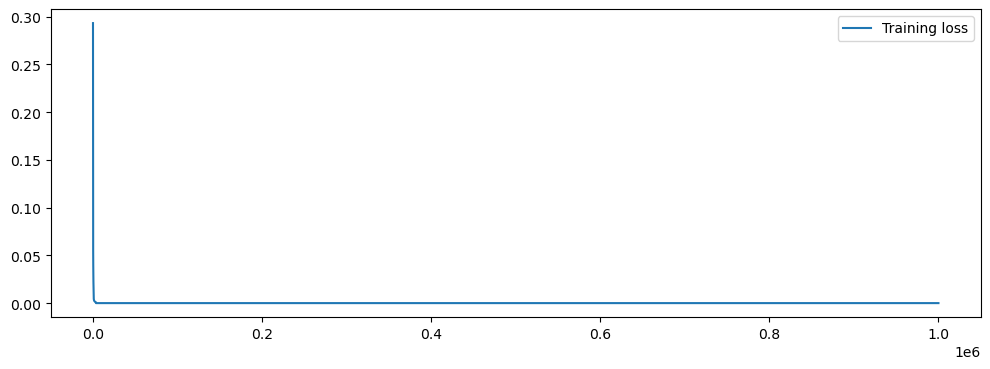

In [37]:
# epoch별 손실값
fig = plt.figure(figsize=(12, 4))
plt.plot(train_hist, label="Training loss")
plt.legend()
plt.show()
plt.close()

In [57]:
with torch.no_grad():
    predicted = model(X_test_tensor)
    y_pred = predicted.cpu()[:, 0, :]
    y_test = y_test_tensor.cpu()[:, 0, :]

    y_pred = scaler.inverse_transform(y_pred)[:, 0]
    y_test = scaler.inverse_transform(y_test)[:, 0]

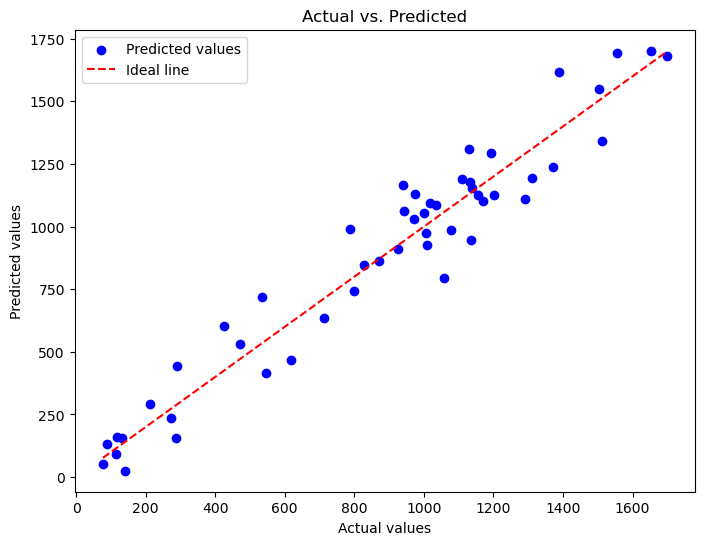

In [58]:
# 1. Actual vs. Predicted Plot
fig, ax = plt.subplots(figsize=(8, 6))  # 새로운 플롯 초기화
ax.scatter(y_test, y_pred, color='blue', label='Predicted values')
ax.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', label='Ideal line')
ax.set_xlabel('Actual values')
ax.set_ylabel('Predicted values')
ax.set_title('Actual vs. Predicted')
fig.savefig(RESULT_PREDICTION_DIR / "actual_vs_predicted.png")
plt.legend()
plt.show()
plt.close(fig)

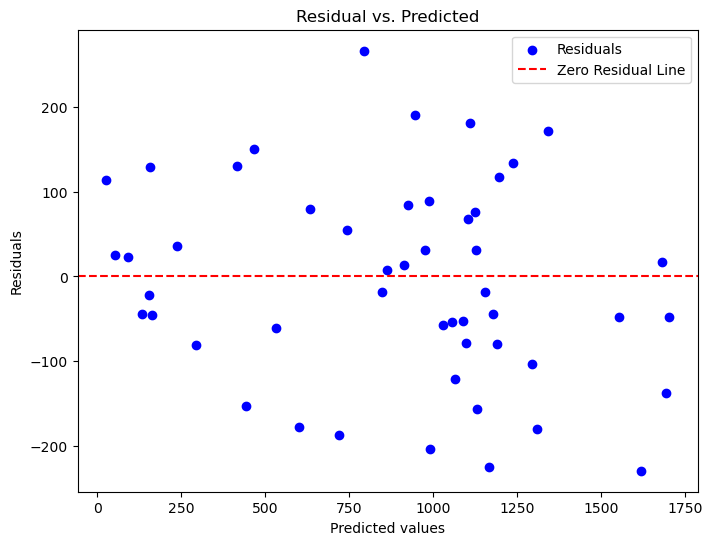

In [59]:
# 2. Residual vs. Predicted Plot
residuals = y_test - y_pred
fig, ax = plt.subplots(figsize=(8, 6))  # 새로운 플롯 초기화
ax.scatter(y_pred, residuals, color='blue', label='Residuals')
ax.axhline(y=0, color='red', linestyle='--', label='Zero Residual Line')
ax.set_xlabel('Predicted values')
ax.set_ylabel('Residuals')
ax.set_title('Residual vs. Predicted')
fig.savefig(RESULT_PREDICTION_DIR / "residual_vs_predicted.png")
plt.legend()
plt.show()
plt.close(fig)


In [ ]:
y_pred = np.array(y_pred, dtype=np.float64)
y_test = np.array(y_test, dtype=np.float64)

y_mean = np.mean(y_test)

# SST 계산: 실제 값과 평균 사이의 차이의 제곱합
SST = np.sum((y_test - y_mean) ** 2)

# SSR 계산: 예측 값과 실제 값 평균 사이의 차이의 제곱합
SSR = np.sum((y_pred - y_mean) ** 2)

# SSE 계산: 실제 값과 예측 값 사이의 차이의 제곱합
SSE = np.sum((y_test - y_pred) ** 2)

# 두 가지 방식으로 R² 계산
r2_from_ssr = np.round(SSR / SST, decimals=10)
r2_from_sse = np.round(1 - (SSE / SST), decimals=10)

# MSE 계산
mse = np.mean((y_test - y_pred) ** 2)
rmse = np.sqrt(mse)
mae = np.mean(np.abs(y_test - y_pred))

# 결과 출력
print(f'1 - SSE / SST (R²): {r2_from_sse}')
print(f'MSE: {mse}')
print(f'RMSE: {rmse}')
print(f'MAE: {mae}')

1 - SSE / SST (R²): 0.9313033301
MSE: 13753.736589289692
RMSE: 117.27632578355144
MAE: 96.86802798539401


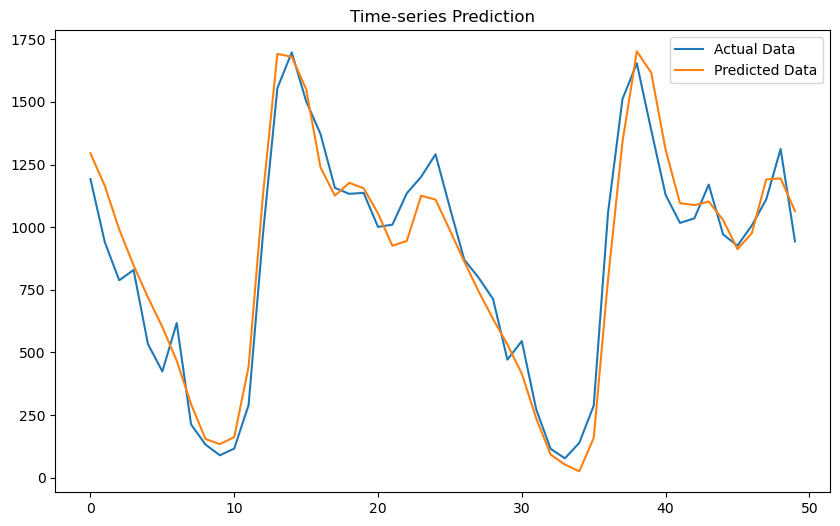

In [46]:
# 결과 시각화
plt.figure(figsize=(10, 6))

# 실제 데이터와 예측 데이터를 플롯
plt.plot(y_test, label='Actual Data')
plt.plot(y_pred, label='Predicted Data')

# 그래프 제목과 범례 설정
plt.title('Time-series Prediction')
plt.legend()
plt.show()

In [29]:
X, y = make_sample(scaled, 24, 0)

In [30]:
X = torch.Tensor(X).to(device)

In [48]:
with torch.no_grad():
    predicted = model(X)
    y_pred = predicted.cpu()[:-1, 0, :]
    last_y_pred = predicted.cpu()[-1, :, :]
    pred = torch.cat((y_pred, last_y_pred), dim=0)

predicted = scaler.inverse_transform(pred)

In [49]:
pred_df = time_grouped_df.copy()
last_timestamp = pred_df.index[-1]
new_timestamp = pd.date_range(last_timestamp, periods=6 + 1, freq='h')[1:]  # 마지막 시간 제외
new_index = pred_df.index.to_list() + new_timestamp.to_list()
pred_df = pred_df.reindex(new_index)

pred_df['pred'] = None
pred_df.iloc[24:, pred_df.columns.get_loc('pred')] = predicted[:,0]

In [50]:
plot_df = pred_df.copy()
plot_df["end_time_floor"] = plot_df.index
plot_df.index = range(len(plot_df))

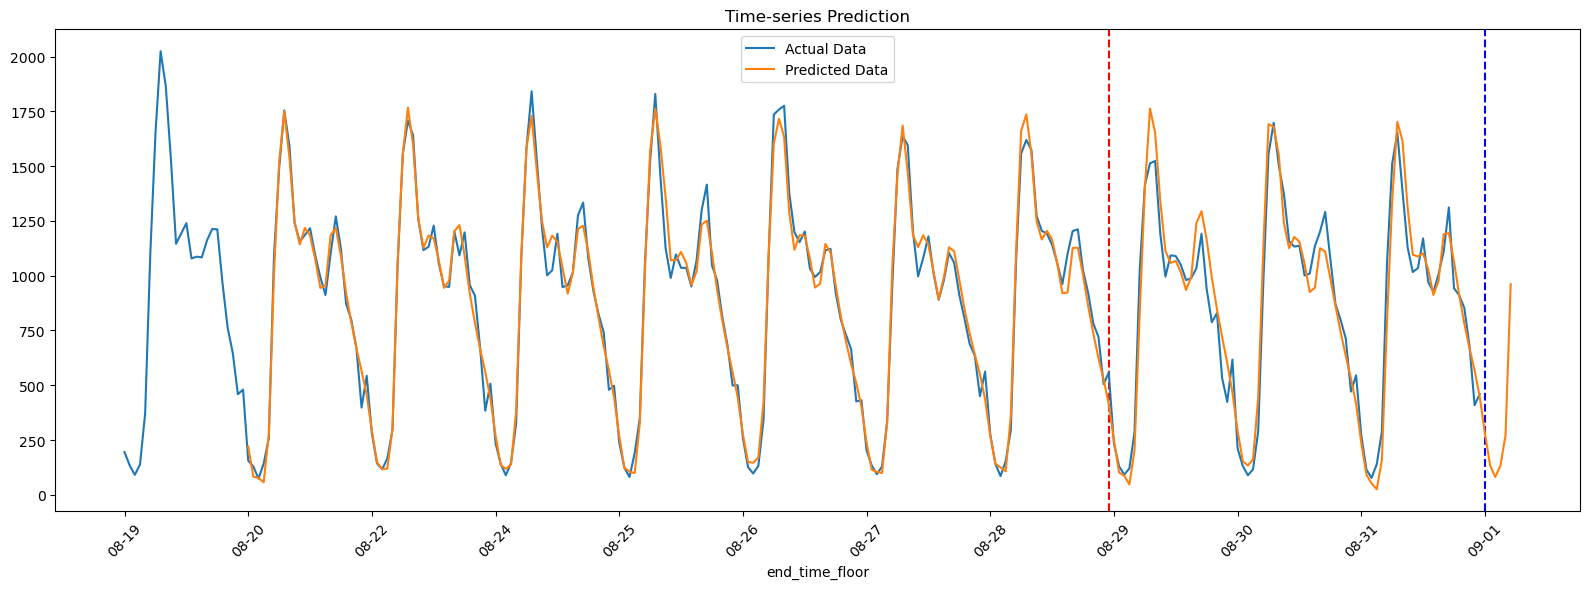

In [55]:
# 결과 시각화
fig, ax = plt.subplots(figsize=(16, 6))

# 훈련/테스트 구분 날짜에 빨간 세로선 추가
ax.axvline(x = plot_df.index[-79], color='r', linestyle='--')
ax.axvline(x = plot_df.index[-6], color='b', linestyle='--')

# 실제 데이터와 예측 데이터를 플롯
ax.plot(plot_df['count'], label='Actual Data')
ax.plot(plot_df['pred'], label='Predicted Data')

# 그래프 제목과 범례 설정
day_starts = plot_df.groupby(plot_df["end_time_floor"].dt.normalize()).head(1)
ax.set_xticks(
    day_starts.index,
    day_starts["end_time_floor"].dt.strftime("%m-%d"),
    rotation=45
)

ax.set_title('Time-series Prediction')
ax.set_xlabel('end_time_floor')
ax.legend()
fig.savefig(RESULT_PREDICTION_DIR / "all_time_series_prediction.png")
plt.tight_layout()
plt.show()
plt.close(fig)

In [35]:
output_df = pred_df[['count', 'pred']]
output_path = RESULT_PREDICTION_DIR / "gru_prediction.csv"
output_df.to_csv(output_path, index=True)